In [37]:
import pandas as pd         
import numpy as np                    
import matplotlib.pyplot as plt              
import seaborn as sns            

In [38]:
df_hr = pd.read_csv("Cow_01_2020-06-24_07-38-58.CSV",
                    encoding="utf-8")

C:\Users\Owner\AppData\Local\Temp\ipykernel_25288\2574047673.py:1: DtypeWarning: Columns (0: Date, 1: Start time, 2: Duration, 3: Total distance (mi), 4: Average heart rate (bpm), 5: Average speed (mi/h), 6: Max speed (mi/h), 7: Average pace (min/mi), 8: Max pace (min/mi), 9: Height (ft in)) have mixed types. Specify dtype option on import or set low_memory=False.
  df_hr = pd.read_csv("Cow_01_2020-06-24_07-38-58.CSV",


In [39]:
df_bhve = pd.read_csv("AndroSensor_Cow_1_new.csv")

In [40]:
df_bhve.info()

<class 'pandas.DataFrame'>
RangeIndex: 187600 entries, 0 to 187599
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ACCELEROMETER X (m/s²)         187600 non-null  float64
 1   ACCELEROMETER Y (m/s²)         187600 non-null  float64
 2   ACCELEROMETER Z (m/s²)         187600 non-null  float64
 3   LOCATION Latitude :            187600 non-null  float64
 4   LOCATION Longitude :           187600 non-null  float64
 5   LOCATION Altitude ( m)         153445 non-null  float64
 6   LOCATION Altitude-google ( m)  0 non-null       float64
 7   LOCATION Speed ( Mph)          153412 non-null  float64
 8   LOCATION Accuracy ( m)         187600 non-null  float64
 9   LOCATION ORIENTATION (°)       153412 non-null  float64
 10  Satellites in range            187600 non-null  str    
 11  Time since start in ms         187600 non-null  int64  
 12  YYYY-MO-DD HH-MI-SS_SSS        187600 non

In [88]:
df_bhve["YYYY-MO-DD HH-MI-SS_SSS"][0].split()[0]

'2020-06-24'

# Behavior --> 🌟

In [89]:
df_bhve["new_time"] =[x.split()[1] for x in df_bhve["YYYY-MO-DD HH-MI-SS_SSS"]]

In [90]:
df_bhve["new_date"] =[x.split()[0] for x in df_bhve["YYYY-MO-DD HH-MI-SS_SSS"]]

In [91]:
df_bhve["time_only"] = df_bhve["new_time"].str.extract(r"(\d{2}:\d{2}:\d{2})")

In [92]:
df_bhve["datetime_only"] = pd.to_datetime(
    df_bhve["new_date"] + " " + df_bhve["time_only"],
    format="%Y-%m-%d %H:%M:%S"
)

In [93]:
df_bhve

,ACCELEROMETER X (m/s²),ACCELEROMETER Y (m/s²),ACCELEROMETER Z (m/s²),LOCATION Latitude :,LOCATION Longitude :,LOCATION Altitude ( m),LOCATION Altitude-google ( m),LOCATION Speed ( Mph),LOCATION Accuracy ( m),LOCATION ORIENTATION (°),Satellites in range,Time since start in ms,YYYY-MO-DD HH-MI-SS_SSS,new_time,new_date,time_only,datetime_only
0,-1.356,5.186,8.098,38.102497,-84.75629,253.8,NaN,0.0,10.600000,0.0,12-Jun,8,2020-06-24 07:39:17:708,07:39:17:708,2020-06-24,07:39:17,2020-06-24 07:39:17
1,-1.085,5.060,8.142,38.102500,-84.75630,253.7,NaN,0.0,9.800000,0.0,12-Jul,1008,2020-06-24 07:39:18:708,07:39:18:708,2020-06-24,07:39:18,2020-06-24 07:39:18
2,-1.046,4.908,7.920,38.102524,-84.75638,253.6,NaN,0.0,8.900000,0.0,12-Jul,2009,2020-06-24 07:39:19:709,07:39:19:709,2020-06-24,07:39:19,2020-06-24 07:39:19
3,-3.416,2.844,10.054,38.102530,-84.75640,253.5,NaN,0.0,8.400000,0.0,12-Jul,3009,2020-06-24 07:39:20:709,07:39:20:709,2020-06-24,07:39:20,2020-06-24 07:39:20
4,-1.440,-3.453,10.276,38.102540,-84.75642,253.4,NaN,0.0,8.100000,0.0,12-Jul,4008,2020-06-24 07:39:21:708,07:39:21:708,2020-06-24,07:39:21,2020-06-24 07:39:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187595,-4.931,-3.313,7.843,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187595640,2020-06-26 11:45:53:340,11:45:53:340,2020-06-26,11:45:53,2020-06-26 11:45:53
187596,-5.056,-3.601,7.955,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187596640,2020-06-26 11:45:54:340,11:45:54:340,2020-06-26,11:45:54,2020-06-26 11:45:54
187597,-4.889,-4.016,8.175,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187597640,2020-06-26 11:45:55:340,11:45:55:340,2020-06-26,11:45:55,2020-06-26 11:45:55
187598,-5.979,-1.114,8.323,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187598640,2020-06-26 11:45:56:340,11:45:56:340,2020-06-26,11:45:56,2020-06-26 11:45:56


# Heart Rate --> 🔥

In [61]:
df_hr.head()

,Name,Sport,Date,Start time,Duration,Total distance (mi),Average heart rate (bpm),Average speed (mi/h),Max speed (mi/h),Average pace (min/mi),...,Ascent (ft),Descent (ft),Average power (W),Max power (W),Notes,Height (ft in),Weight (lbs),HR max,HR sit,VO2max
0,Cow 01,RUNNING,24-06-2020,7:38:58,49:43:48,0,69,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5 7,189.6,NaN,NaN,NaN
1,Sample rate,Time,HR (bpm),Speed (mi/h),Pace (min/mi),Cadence,Altitude (ft),Stride length (in),Distances (ft),Temperatures (F),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7:38:58,0:00:00,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7:38:59,0:00:01,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7:39:00,0:00:02,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_hr.columns

Index(['Name', 'Sport', 'Date', 'Start time', 'Duration',
       'Total distance (mi)', 'Average heart rate (bpm)',
       'Average speed (mi/h)', 'Max speed (mi/h)', 'Average pace (min/mi)',
       'Max pace (min/mi)', 'Calories', 'Fat percentage of calories(%)',
       'Average cadence (rpm)', 'Average stride length (in)', 'Running index',
       'Training load', 'Ascent (ft)', 'Descent (ft)', 'Average power (W)',
       'Max power (W)', 'Notes', 'Height (ft in)', 'Weight (lbs)', 'HR max',
       'HR sit', 'VO2max'],
      dtype='str')

In [74]:
dfx =df_hr[["Name","Sport", "Date", "Start time"]]

In [75]:
dfx

,Name,Sport,Date,Start time
0,Cow 01,RUNNING,24-06-2020,7:38:58
1,Sample rate,Time,HR (bpm),Speed (mi/h)
2,7:38:58,0:00:00,99,NaN
3,7:38:59,0:00:01,99,NaN
4,7:39:00,0:00:02,99,NaN
...,...,...,...,...
179025,9:22:41,49:43:43,0,NaN
179026,9:22:42,49:43:44,0,NaN
179027,9:22:43,49:43:45,0,NaN
179028,9:22:44,49:43:46,0,NaN


In [78]:
activity_date = dfx.iloc[0, 2]
start_time = dfx.iloc[0, 3]

print(activity_date)
print(start_time)

24-06-2020
7:38:58


In [ ]:
start_dt = pd.to_datetime(
    f"{activity_date} {start_time}",
    format="%d-%m-%Y %H:%M:%S"
)

start_dt

Timestamp('2020-06-24 07:38:58')

In [83]:
dx = dfx.iloc[2:,:].rename(columns={"Name":"DATE",
                       "Date": "HR"})

In [84]:
dx

,DATE,Sport,HR,Start time
2,7:38:58,0:00:00,99,NaN
3,7:38:59,0:00:01,99,NaN
4,7:39:00,0:00:02,99,NaN
5,7:39:01,0:00:03,99,NaN
6,7:39:02,0:00:04,99,NaN
...,...,...,...,...
179025,9:22:41,49:43:43,0,NaN
179026,9:22:42,49:43:44,0,NaN
179027,9:22:43,49:43:45,0,NaN
179028,9:22:44,49:43:46,0,NaN


In [86]:
dx["datetime"] = (
    start_dt +
    pd.to_timedelta(dx["Sport"])
)

In [87]:
dx.head()

,DATE,Sport,HR,Start time,datetime
2,7:38:58,0:00:00,99,NaN,2020-06-24 07:38:58
3,7:38:59,0:00:01,99,NaN,2020-06-24 07:38:59
4,7:39:00,0:00:02,99,NaN,2020-06-24 07:39:00
5,7:39:01,0:00:03,99,NaN,2020-06-24 07:39:01
6,7:39:02,0:00:04,99,NaN,2020-06-24 07:39:02


# Combined Data --> 🔥

In [94]:
dx.set_index("datetime", inplace=True)

In [95]:
df_bhve.set_index("datetime_only", inplace=True)

In [100]:
df_bhve

,ACCELEROMETER X (m/s²),ACCELEROMETER Y (m/s²),ACCELEROMETER Z (m/s²),LOCATION Latitude :,LOCATION Longitude :,LOCATION Altitude ( m),LOCATION Altitude-google ( m),LOCATION Speed ( Mph),LOCATION Accuracy ( m),LOCATION ORIENTATION (°),Satellites in range,Time since start in ms,YYYY-MO-DD HH-MI-SS_SSS,new_time,new_date,time_only
datetime_only,,,,,,,,,,,,,,,,
2020-06-24 07:39:17,-1.356,5.186,8.098,38.102497,-84.75629,253.8,NaN,0.0,10.600000,0.0,12-Jun,8,2020-06-24 07:39:17:708,07:39:17:708,2020-06-24,07:39:17
2020-06-24 07:39:18,-1.085,5.060,8.142,38.102500,-84.75630,253.7,NaN,0.0,9.800000,0.0,12-Jul,1008,2020-06-24 07:39:18:708,07:39:18:708,2020-06-24,07:39:18
2020-06-24 07:39:19,-1.046,4.908,7.920,38.102524,-84.75638,253.6,NaN,0.0,8.900000,0.0,12-Jul,2009,2020-06-24 07:39:19:709,07:39:19:709,2020-06-24,07:39:19
2020-06-24 07:39:20,-3.416,2.844,10.054,38.102530,-84.75640,253.5,NaN,0.0,8.400000,0.0,12-Jul,3009,2020-06-24 07:39:20:709,07:39:20:709,2020-06-24,07:39:20
2020-06-24 07:39:21,-1.440,-3.453,10.276,38.102540,-84.75642,253.4,NaN,0.0,8.100000,0.0,12-Jul,4008,2020-06-24 07:39:21:708,07:39:21:708,2020-06-24,07:39:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 11:45:53,-4.931,-3.313,7.843,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187595640,2020-06-26 11:45:53:340,11:45:53:340,2020-06-26,11:45:53
2020-06-26 11:45:54,-5.056,-3.601,7.955,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187596640,2020-06-26 11:45:54:340,11:45:54:340,2020-06-26,11:45:54
2020-06-26 11:45:55,-4.889,-4.016,8.175,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187597640,2020-06-26 11:45:55:340,11:45:55:340,2020-06-26,11:45:55


In [98]:
dx

,DATE,Sport,HR,Start time
datetime,,,,
2020-06-24 07:38:58,7:38:58,0:00:00,99,NaN
2020-06-24 07:38:59,7:38:59,0:00:01,99,NaN
2020-06-24 07:39:00,7:39:00,0:00:02,99,NaN
2020-06-24 07:39:01,7:39:01,0:00:03,99,NaN
2020-06-24 07:39:02,7:39:02,0:00:04,99,NaN
...,...,...,...,...
2020-06-26 09:22:41,9:22:41,49:43:43,0,NaN
2020-06-26 09:22:42,9:22:42,49:43:44,0,NaN
2020-06-26 09:22:43,9:22:43,49:43:45,0,NaN


# Merge Files --> 😀

In [101]:
matched_df = pd.merge_asof(
    df_bhve,
    dx,
    left_index=True,
    right_index=True,
    direction="nearest"
)

In [102]:
matched_df

,ACCELEROMETER X (m/s²),ACCELEROMETER Y (m/s²),ACCELEROMETER Z (m/s²),LOCATION Latitude :,LOCATION Longitude :,LOCATION Altitude ( m),LOCATION Altitude-google ( m),LOCATION Speed ( Mph),LOCATION Accuracy ( m),LOCATION ORIENTATION (°),Satellites in range,Time since start in ms,YYYY-MO-DD HH-MI-SS_SSS,new_time,new_date,time_only,DATE,Sport,HR,Start time
datetime_only,,,,,,,,,,,,,,,,,,,,
2020-06-24 07:39:17,-1.356,5.186,8.098,38.102497,-84.75629,253.8,NaN,0.0,10.600000,0.0,12-Jun,8,2020-06-24 07:39:17:708,07:39:17:708,2020-06-24,07:39:17,7:39:17,0:00:19,96,NaN
2020-06-24 07:39:18,-1.085,5.060,8.142,38.102500,-84.75630,253.7,NaN,0.0,9.800000,0.0,12-Jul,1008,2020-06-24 07:39:18:708,07:39:18:708,2020-06-24,07:39:18,7:39:18,0:00:20,97,NaN
2020-06-24 07:39:19,-1.046,4.908,7.920,38.102524,-84.75638,253.6,NaN,0.0,8.900000,0.0,12-Jul,2009,2020-06-24 07:39:19:709,07:39:19:709,2020-06-24,07:39:19,7:39:19,0:00:21,97,NaN
2020-06-24 07:39:20,-3.416,2.844,10.054,38.102530,-84.75640,253.5,NaN,0.0,8.400000,0.0,12-Jul,3009,2020-06-24 07:39:20:709,07:39:20:709,2020-06-24,07:39:20,7:39:20,0:00:22,98,NaN
2020-06-24 07:39:21,-1.440,-3.453,10.276,38.102540,-84.75642,253.4,NaN,0.0,8.100000,0.0,12-Jul,4008,2020-06-24 07:39:21:708,07:39:21:708,2020-06-24,07:39:21,7:39:21,0:00:23,99,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 11:45:53,-4.931,-3.313,7.843,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187595640,2020-06-26 11:45:53:340,11:45:53:340,2020-06-26,11:45:53,9:22:45,49:43:47,0,NaN
2020-06-26 11:45:54,-5.056,-3.601,7.955,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187596640,2020-06-26 11:45:54:340,11:45:54:340,2020-06-26,11:45:54,9:22:45,49:43:47,0,NaN
2020-06-26 11:45:55,-4.889,-4.016,8.175,38.026580,-84.50985,270.7,NaN,NaN,28.038998,NaN,17-Dec,187597640,2020-06-26 11:45:55:340,11:45:55:340,2020-06-26,11:45:55,9:22:45,49:43:47,0,NaN


In [103]:
matched_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 187600 entries, 2020-06-24 07:39:17 to 2020-06-26 11:45:57
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ACCELEROMETER X (m/s²)         187600 non-null  float64
 1   ACCELEROMETER Y (m/s²)         187600 non-null  float64
 2   ACCELEROMETER Z (m/s²)         187600 non-null  float64
 3   LOCATION Latitude :            187600 non-null  float64
 4   LOCATION Longitude :           187600 non-null  float64
 5   LOCATION Altitude ( m)         153445 non-null  float64
 6   LOCATION Altitude-google ( m)  0 non-null       float64
 7   LOCATION Speed ( Mph)          153412 non-null  float64
 8   LOCATION Accuracy ( m)         187600 non-null  float64
 9   LOCATION ORIENTATION (°)       153412 non-null  float64
 10  Satellites in range            187600 non-null  str    
 11  Time since start in ms         187600 non-null  int64  
 12  YYYY-MO

In [ ]:
# matched_df.to_csv("combined_data.csv", index=False)

In [105]:
matched_df.head()

,ACCELEROMETER X (m/s²),ACCELEROMETER Y (m/s²),ACCELEROMETER Z (m/s²),LOCATION Latitude :,LOCATION Longitude :,LOCATION Altitude ( m),LOCATION Altitude-google ( m),LOCATION Speed ( Mph),LOCATION Accuracy ( m),LOCATION ORIENTATION (°),Satellites in range,Time since start in ms,YYYY-MO-DD HH-MI-SS_SSS,new_time,new_date,time_only,DATE,Sport,HR,Start time
datetime_only,,,,,,,,,,,,,,,,,,,,
2020-06-24 07:39:17,-1.356,5.186,8.098,38.102497,-84.75629,253.8,NaN,0.0,10.6,0.0,12-Jun,8,2020-06-24 07:39:17:708,07:39:17:708,2020-06-24,07:39:17,7:39:17,0:00:19,96,NaN
2020-06-24 07:39:18,-1.085,5.060,8.142,38.102500,-84.75630,253.7,NaN,0.0,9.8,0.0,12-Jul,1008,2020-06-24 07:39:18:708,07:39:18:708,2020-06-24,07:39:18,7:39:18,0:00:20,97,NaN
2020-06-24 07:39:19,-1.046,4.908,7.920,38.102524,-84.75638,253.6,NaN,0.0,8.9,0.0,12-Jul,2009,2020-06-24 07:39:19:709,07:39:19:709,2020-06-24,07:39:19,7:39:19,0:00:21,97,NaN
2020-06-24 07:39:20,-3.416,2.844,10.054,38.102530,-84.75640,253.5,NaN,0.0,8.4,0.0,12-Jul,3009,2020-06-24 07:39:20:709,07:39:20:709,2020-06-24,07:39:20,7:39:20,0:00:22,98,NaN
2020-06-24 07:39:21,-1.440,-3.453,10.276,38.102540,-84.75642,253.4,NaN,0.0,8.1,0.0,12-Jul,4008,2020-06-24 07:39:21:708,07:39:21:708,2020-06-24,07:39:21,7:39:21,0:00:23,99,NaN


In [106]:
matched_df.columns

Index(['ACCELEROMETER X (m/s²)', 'ACCELEROMETER Y (m/s²)',
       'ACCELEROMETER Z (m/s²)', 'LOCATION Latitude : ',
       'LOCATION Longitude : ', 'LOCATION Altitude ( m)',
       'LOCATION Altitude-google ( m)', 'LOCATION Speed ( Mph)',
       'LOCATION Accuracy ( m)', 'LOCATION ORIENTATION (°)',
       'Satellites in range', 'Time since start in ms ',
       'YYYY-MO-DD HH-MI-SS_SSS', 'new_time', 'new_date', 'time_only', 'DATE',
       'Sport', 'HR', 'Start time'],
      dtype='str')

# FINAL DATA --.

In [135]:
matched_df.columns

Index(['ACCELEROMETER X (m/s²)', 'ACCELEROMETER Y (m/s²)',
       'ACCELEROMETER Z (m/s²)', 'LOCATION Latitude : ',
       'LOCATION Longitude : ', 'LOCATION Altitude ( m)',
       'LOCATION Altitude-google ( m)', 'LOCATION Speed ( Mph)',
       'LOCATION Accuracy ( m)', 'LOCATION ORIENTATION (°)',
       'Satellites in range', 'Time since start in ms ',
       'YYYY-MO-DD HH-MI-SS_SSS', 'new_time', 'new_date', 'time_only', 'DATE',
       'Sport', 'HR', 'Start time'],
      dtype='str')

In [137]:
selected_columns = ['ACCELEROMETER X (m/s²)', 
                    'ACCELEROMETER Y (m/s²)',
                    'ACCELEROMETER Z (m/s²)', 
                    'LOCATION Latitude : ',
                    'LOCATION Longitude : ', 
                    'LOCATION Speed ( Mph)',
                                    'HR']

final_df = matched_df[selected_columns]

In [158]:
final_df = final_df.sort_index()

In [159]:
final_df["HR"] = pd.to_numeric(final_df["HR"])

In [160]:
final_df

,ACCELEROMETER X (m/s²),ACCELEROMETER Y (m/s²),ACCELEROMETER Z (m/s²),LOCATION Latitude :,LOCATION Longitude :,LOCATION Speed ( Mph),HR
datetime_only,,,,,,,
2020-06-24 07:39:17,-1.356,5.186,8.098,38.102497,-84.75629,0.0,96
2020-06-24 07:39:18,-1.085,5.060,8.142,38.102500,-84.75630,0.0,97
2020-06-24 07:39:19,-1.046,4.908,7.920,38.102524,-84.75638,0.0,97
2020-06-24 07:39:20,-3.416,2.844,10.054,38.102530,-84.75640,0.0,98
2020-06-24 07:39:21,-1.440,-3.453,10.276,38.102540,-84.75642,0.0,99
...,...,...,...,...,...,...,...
2020-06-26 11:45:53,-4.931,-3.313,7.843,38.026580,-84.50985,NaN,0
2020-06-26 11:45:54,-5.056,-3.601,7.955,38.026580,-84.50985,NaN,0
2020-06-26 11:45:55,-4.889,-4.016,8.175,38.026580,-84.50985,NaN,0


In [162]:
final_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 187600 entries, 2020-06-24 07:39:17 to 2020-06-26 11:45:57
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ACCELEROMETER X (m/s²)  187600 non-null  float64
 1   ACCELEROMETER Y (m/s²)  187600 non-null  float64
 2   ACCELEROMETER Z (m/s²)  187600 non-null  float64
 3   LOCATION Latitude :     187600 non-null  float64
 4   LOCATION Longitude :    187600 non-null  float64
 5   LOCATION Speed ( Mph)   153412 non-null  float64
 6   HR                      187600 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 11.5 MB


In [163]:
final_df["LOCATION Longitude : "].iloc[0]

np.float64(-84.75629)

In [167]:
final_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 187600 entries, 2020-06-24 07:39:17 to 2020-06-26 11:45:57
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ACCELEROMETER X (m/s²)  187600 non-null  float64
 1   ACCELEROMETER Y (m/s²)  187600 non-null  float64
 2   ACCELEROMETER Z (m/s²)  187600 non-null  float64
 3   LOCATION Latitude :     187600 non-null  float64
 4   LOCATION Longitude :    187600 non-null  float64
 5   LOCATION Speed ( Mph)   153412 non-null  float64
 6   HR                      187600 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 11.5 MB


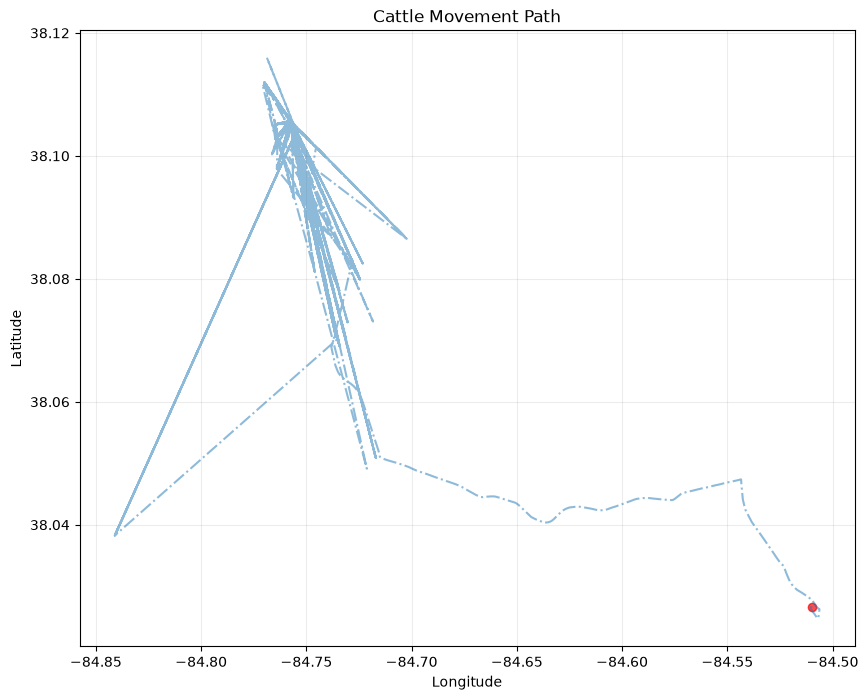

In [171]:
plt.figure(figsize=(10,8))

plt.plot(
    final_df["LOCATION Longitude : "],
    final_df["LOCATION Latitude : "],
    alpha=0.5,
    linestyle="-."
    
)

plt.scatter(
    final_df["LOCATION Longitude : "].iloc[-1],
    final_df["LOCATION Latitude : "].iloc[-1],
    alpha=0.7,
    color="red"
    
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Cattle Movement Path")
plt.grid(alpha=0.15, color="gray")
plt.show()

In [172]:
final_df.head()

,ACCELEROMETER X (m/s²),ACCELEROMETER Y (m/s²),ACCELEROMETER Z (m/s²),LOCATION Latitude :,LOCATION Longitude :,LOCATION Speed ( Mph),HR
datetime_only,,,,,,,
2020-06-24 07:39:17,-1.356,5.186,8.098,38.102497,-84.75629,0.0,96
2020-06-24 07:39:18,-1.085,5.060,8.142,38.102500,-84.75630,0.0,97
2020-06-24 07:39:19,-1.046,4.908,7.920,38.102524,-84.75638,0.0,97
2020-06-24 07:39:20,-3.416,2.844,10.054,38.102530,-84.75640,0.0,98
2020-06-24 07:39:21,-1.440,-3.453,10.276,38.102540,-84.75642,0.0,99


In [179]:
final_df[final_df.isnull()]

,ACCELEROMETER X (m/s²),ACCELEROMETER Y (m/s²),ACCELEROMETER Z (m/s²),LOCATION Latitude :,LOCATION Longitude :,LOCATION Speed ( Mph),HR
datetime_only,,,,,,,
2020-06-24 07:39:17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-24 07:39:18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-24 07:39:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-24 07:39:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-24 07:39:21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2020-06-26 11:45:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-26 11:45:54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-06-26 11:45:55,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_df.dropna()